# PulmoScan AI — Lung Cancer Classification
**Multi-Model Training & Selection Notebook**

This notebook:
1. Loads the organized CT scan dataset
2. Trains **3 candidate models** (EfficientNetB3, EfficientNetB4, ResNet50V2)
3. Evaluates each and selects the best (target: ≥ 0.98 accuracy)
4. Saves the winning model to `weights/lung_cancer_model.h5`
5. Generates full evaluation report + Grad-CAM visualization

**Classes**: Adenocarcinoma | Large Cell Carcinoma | Normal | Squamous Cell Carcinoma

## 0. Setup & Imports

In [48]:
import os
import sys
import json
import shutil
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

# TensorFlow
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB3, EfficientNetB4, ResNet50V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.mixed_precision import set_global_policy

# Scikit-learn
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# PIL
from PIL import Image

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU devices        : {[g.name for g in gpus]}")
else:
    print("Running on CPU — training will be slower")

# Seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version : 2.17.0
NumPy version      : 1.26.4
GPU available      : False
Running on CPU — training will be slower


## 1. Configuration

In [49]:
# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR    = Path(".")                        # ml_model/
DATA_DIR    = BASE_DIR / "data" / "organized"
WEIGHTS_DIR = BASE_DIR / "weights"
WEIGHTS_DIR.mkdir(exist_ok=True)

# ── Dataset ────────────────────────────────────────────────────────────
CLASS_NAMES = ["Adenocarcinoma", "Large Cell Carcinoma", "Normal", "Squamous Cell Carcinoma"]
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16    # lower = safer on CPU; increase to 32 if GPU available

# ── Training ───────────────────────────────────────────────────────────
PHASE1_EPOCHS    = 30      # head-only training
PHASE2_EPOCHS    = 20      # fine-tuning
LEARNING_RATE    = 1e-3
FINE_TUNE_LR     = 1e-5
TARGET_ACCURACY  = 0.98    # minimum required

# Verify dataset exists
assert (DATA_DIR / "train").exists(), \
    f"Dataset not found at {DATA_DIR}. Run: python download_dataset.py first!"

print(f"Dataset root   : {DATA_DIR.resolve()}")
print(f"Weights dir    : {WEIGHTS_DIR.resolve()}")
print(f"Classes        : {CLASS_NAMES}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Target accuracy: {TARGET_ACCURACY*100:.0f}%")

Dataset root   : D:\Projects\CapstoneProject\System\TRY_06\ml_model\data\organized
Weights dir    : D:\Projects\CapstoneProject\System\TRY_06\ml_model\weights
Classes        : ['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']
Batch size     : 16
Target accuracy: 98%


## 2. Dataset Exploration

In [50]:
def count_images(split: str) -> dict:
    counts = {}
    split_dir = DATA_DIR / split
    if not split_dir.exists():
        return counts
    for cls_dir in sorted(split_dir.iterdir()):
        if cls_dir.is_dir():
            images = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.jpeg")) + list(cls_dir.glob("*.png"))
            counts[cls_dir.name] = len(images)
    return counts

print("Dataset Statistics")
print("=" * 50)
totals = {"train": 0, "val": 0, "test": 0}
for split in ["train", "val", "test"]:
    counts = count_images(split)
    print(f"\n{split.upper()}:")
    for cls, n in counts.items():
        print(f"  {cls:<30} {n:>4} images")
        totals[split] += n
    print(f"  {'TOTAL':<30} {totals[split]:>4} images")

print(f"\nGrand total: {sum(totals.values())} images")

Dataset Statistics

TRAIN:
  Adenocarcinoma                  195 images
  Large Cell Carcinoma            115 images
  Normal                          148 images
  Squamous Cell Carcinoma         155 images
  TOTAL                           613 images

VAL:
  Adenocarcinoma                   23 images
  Large Cell Carcinoma             21 images
  Normal                           13 images
  Squamous Cell Carcinoma          15 images
  TOTAL                            72 images

TEST:
  Adenocarcinoma                  120 images
  Large Cell Carcinoma             51 images
  Normal                           54 images
  Squamous Cell Carcinoma          90 images
  TOTAL                           315 images

Grand total: 1000 images


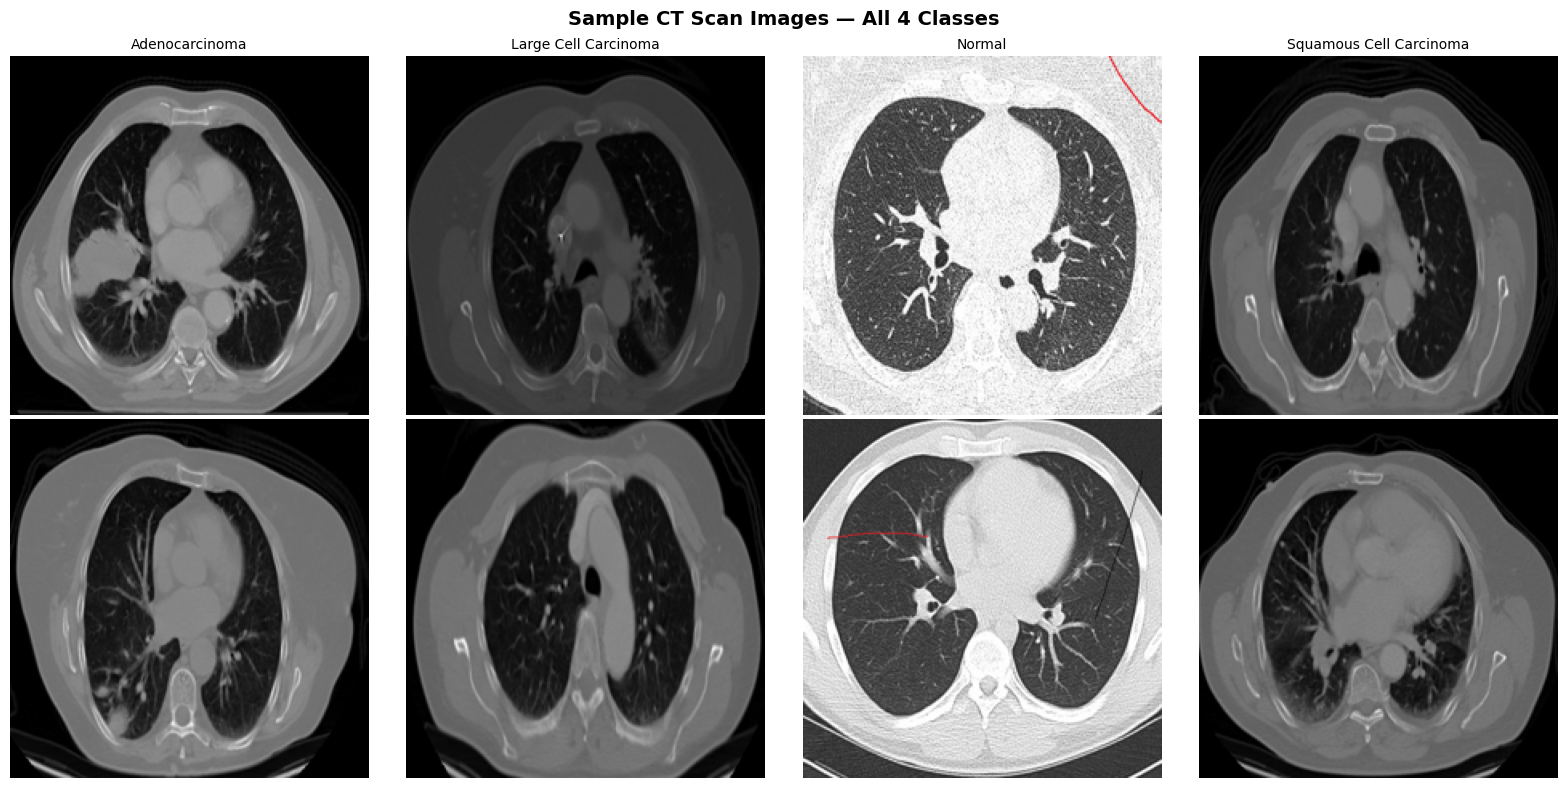

Sample images saved.


In [51]:
# Visualize sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Sample CT Scan Images — All 4 Classes", fontsize=14, fontweight='bold')

for col, cls in enumerate(CLASS_NAMES):
    cls_dir = DATA_DIR / "train" / cls
    if not cls_dir.exists():
        continue
    images = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.jpeg")) + list(cls_dir.glob("*.png"))
    if len(images) < 2:
        continue
    for row in range(2):
        img_path = random.choice(images)
        img = Image.open(img_path).convert("RGB").resize((224, 224))
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls if row == 0 else "", fontsize=10)
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / "sample_images.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Sample images saved.")

## 3. Data Generators

In [52]:
def create_generators(img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    """Create aggressive augmentation generators for training."""

    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.15,
        zoom_range=0.15,
        horizontal_flip=True,
        vertical_flip=False,
        brightness_range=[0.85, 1.15],
        fill_mode="nearest",
    )
    val_datagen = ImageDataGenerator(rescale=1.0 / 255)

    train_gen = train_datagen.flow_from_directory(
        str(DATA_DIR / "train"),
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical",
        classes=CLASS_NAMES,
        shuffle=True,
        seed=SEED,
    )
    val_gen = val_datagen.flow_from_directory(
        str(DATA_DIR / "val"),
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical",
        classes=CLASS_NAMES,
        shuffle=False,
    )
    test_gen = val_datagen.flow_from_directory(
        str(DATA_DIR / "test"),
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical",
        classes=CLASS_NAMES,
        shuffle=False,
    )
    return train_gen, val_gen, test_gen


train_gen, val_gen, test_gen = create_generators()

print(f"Class indices : {train_gen.class_indices}")
print(f"Train batches : {len(train_gen)} ({train_gen.samples} samples)")
print(f"Val batches   : {len(val_gen)} ({val_gen.samples} samples)")
print(f"Test batches  : {len(test_gen)} ({test_gen.samples} samples)")

# Save class indices for backend
with open(str(WEIGHTS_DIR / "class_indices.json"), "w") as f:
    json.dump(train_gen.class_indices, f, indent=2)
print("Class indices saved.")

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Class indices : {'Adenocarcinoma': 0, 'Large Cell Carcinoma': 1, 'Normal': 2, 'Squamous Cell Carcinoma': 3}
Train batches : 39 (613 samples)
Val batches   : 5 (72 samples)
Test batches  : 20 (315 samples)
Class indices saved.


## 4. Model Definitions

In [53]:
def build_efficientnet_b3(num_classes: int = NUM_CLASSES) -> Model:
    """EfficientNetB3 — baseline model from train.py."""
    base = EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="EfficientNetB3")
    return model


def build_efficientnet_b4(num_classes: int = NUM_CLASSES) -> Model:
    """EfficientNetB4 — slightly deeper, often higher accuracy."""
    base = EfficientNetB4(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="EfficientNetB4")
    return model


def build_resnet50v2(num_classes: int = NUM_CLASSES) -> Model:
    """ResNet50V2 — proven architecture, good baseline comparison."""
    base = ResNet50V2(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="ResNet50V2")
    return model


MODEL_BUILDERS = {
    "EfficientNetB3": build_efficientnet_b3,
    "EfficientNetB4": build_efficientnet_b4,
    "ResNet50V2":     build_resnet50v2,
}

print("Model builders defined:", list(MODEL_BUILDERS.keys()))

Model builders defined: ['EfficientNetB3', 'EfficientNetB4', 'ResNet50V2']


## 5. Training Utilities

In [54]:
def get_callbacks(model_name: str, phase: str):
    model_dir = WEIGHTS_DIR / model_name
    model_dir.mkdir(exist_ok=True)
    return [
        callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=8,
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=4,
            min_lr=1e-8,
            verbose=1,
        ),
        callbacks.ModelCheckpoint(
            str(model_dir / f"best_{phase}.keras"),
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1,
        ),
        callbacks.CSVLogger(str(model_dir / f"log_{phase}.csv")),
    ]


def compute_class_weights(train_gen):
    """Compute class weights to handle class imbalance."""
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.array(sorted(set(train_gen.classes)))
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=train_gen.classes,
    )
    class_weight_dict = dict(zip(classes, weights))
    print(f"Class weights: {class_weight_dict}")
    return class_weight_dict


def plot_training_history(histories: dict, model_name: str):
    """Plot training curves for both phases."""
    h1, h2 = histories["phase1"], histories["phase2"]

    acc     = h1.history["accuracy"]     + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss    = h1.history["loss"]         + h2.history["loss"]
    val_loss= h1.history["val_loss"]     + h2.history["val_loss"]
    split_ep = len(h1.history["accuracy"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Training History", fontsize=13, fontweight='bold')

    axes[0].plot(acc,     label="Train Acc",  color='royalblue')
    axes[0].plot(val_acc, label="Val Acc",    color='darkorange')
    axes[0].axvline(split_ep - 1, color='gray', ls='--', label='Fine-tune start')
    axes[0].axhline(TARGET_ACCURACY, color='red', ls=':', label=f'Target {TARGET_ACCURACY*100:.0f}%')
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(loss,     label="Train Loss", color='royalblue')
    axes[1].plot(val_loss, label="Val Loss",   color='darkorange')
    axes[1].axvline(split_ep - 1, color='gray', ls='--')
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    save_path = WEIGHTS_DIR / model_name / "training_history.png"
    plt.savefig(str(save_path), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved to {save_path}")


print("Utilities ready.")

Utilities ready.


## 6. Training Function

In [55]:
def train_model(model_name: str, fine_tune_layers: int = 30):
    """
    Two-phase transfer learning training.
    Phase 1: Freeze base, train head.
    Phase 2: Unfreeze last `fine_tune_layers`, fine-tune with very low LR.
    """
    print("\n" + "=" * 60)
    print(f"  Training: {model_name}")
    print("=" * 60)

    # Fresh generators
    t_gen, v_gen, te_gen = create_generators()
    class_weights = compute_class_weights(t_gen)

    # ── Phase 1: Head only ─────────────────────────────────────────────
    print("\n[Phase 1] Training head (base frozen)...")
    model = MODEL_BUILDERS[model_name]()
    model.compile(
        optimizer=optimizers.AdamW(LEARNING_RATE, weight_decay=1e-4),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )

    h1 = model.fit(
        t_gen,
        epochs=PHASE1_EPOCHS,
        validation_data=v_gen,
        callbacks=get_callbacks(model_name, "phase1"),
        class_weight=class_weights,
        verbose=1,
    )

    best_val_p1 = max(h1.history["val_accuracy"])
    print(f"\nPhase 1 best val accuracy: {best_val_p1*100:.2f}%")

    # ── Phase 2: Fine-tuning ───────────────────────────────────────────
    print(f"\n[Phase 2] Fine-tuning last {fine_tune_layers} layers...")
    # The base model is model.layers[1] (index 1)
    base_layer = None
    for layer in model.layers:
        if hasattr(layer, 'layers') and len(layer.layers) > 5:
            base_layer = layer
            break

    if base_layer:
        base_layer.trainable = True
        for layer in base_layer.layers[:-fine_tune_layers]:
            layer.trainable = False
        trainable_count = sum(1 for l in base_layer.layers if l.trainable)
        print(f"Unfrozen layers in base: {trainable_count}")
    else:
        print("Warning: Could not locate base model layer for fine-tuning")

    model.compile(
        optimizer=optimizers.AdamW(FINE_TUNE_LR, weight_decay=1e-5),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )

    h2 = model.fit(
        t_gen,
        epochs=PHASE2_EPOCHS,
        validation_data=v_gen,
        callbacks=get_callbacks(model_name, "phase2"),
        class_weight=class_weights,
        verbose=1,
    )

    best_val_p2 = max(h2.history["val_accuracy"])
    print(f"\nPhase 2 best val accuracy: {best_val_p2*100:.2f}%")

    # ── Evaluate on test set ───────────────────────────────────────────
    print("\n[Evaluation] Test set...")
    te_gen.reset()
    results = model.evaluate(te_gen, verbose=1)
    test_loss, test_acc, test_auc, test_prec, test_rec = results

    print(f"\n{'='*40}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*40}")
    print(f"  Loss      : {test_loss:.4f}")
    print(f"  Accuracy  : {test_acc*100:.2f}%")
    print(f"  AUC       : {test_auc:.4f}")
    print(f"  Precision : {test_prec:.4f}")
    print(f"  Recall    : {test_rec:.4f}")
    print(f"{'='*40}")

    # Classification report
    te_gen.reset()
    y_pred_probs = model.predict(te_gen, verbose=0)
    y_pred  = np.argmax(y_pred_probs, axis=1)
    y_true  = te_gen.classes

    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        digits=4,
    )
    print("\nClassification Report:")
    print(report)

    # Save model
    model_path = str(WEIGHTS_DIR / model_name / "model.h5")
    model.save(model_path)
    print(f"Model saved to {model_path}")

    # Save report
    report_path = WEIGHTS_DIR / model_name / "evaluation.txt"
    with open(report_path, "w") as f:
        f.write(f"Model         : {model_name}\n")
        f.write(f"Test Loss     : {test_loss:.4f}\n")
        f.write(f"Test Accuracy : {test_acc*100:.2f}%\n")
        f.write(f"Test AUC      : {test_auc:.4f}\n")
        f.write(f"Precision     : {test_prec:.4f}\n")
        f.write(f"Recall        : {test_rec:.4f}\n\n")
        f.write(report)

    plot_training_history({"phase1": h1, "phase2": h2}, model_name)

    return {
        "model_name":   model_name,
        "model":        model,
        "test_accuracy": test_acc,
        "test_auc":     test_auc,
        "test_loss":    test_loss,
        "precision":    test_prec,
        "recall":       test_rec,
        "histories":    {"phase1": h1, "phase2": h2},
        "y_pred":       y_pred,
        "y_true":       y_true,
        "y_pred_probs": y_pred_probs,
    }


print("Train function ready.")

Train function ready.


## 7. Train All Models

> **Tip**: On CPU this takes 1–3 hours. On GPU, 15–30 minutes.
> All intermediate checkpoints are saved — safe to interrupt and resume.


  Training: EfficientNetB3
Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Class weights: {0: 0.7858974358974359, 1: 1.3326086956521739, 2: 1.035472972972973, 3: 0.9887096774193549}

[Phase 1] Training head (base frozen)...
Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3245 - auc: 0.5862 - loss: 2.1487 - precision: 0.3427 - recall: 0.2694
Epoch 1: val_accuracy improved from None to 0.40278, saving model to weights\EfficientNetB3\best_phase1.keras

Epoch 1: finished saving model to weights\EfficientNetB3\best_phase1.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.3687 - auc: 0.6330 - loss: 1.8704 - precision: 0.3898 - recall: 0.3002 - val_accuracy: 0.4028 - val_auc: 0.6029 - val_loss: 1.3424 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 950ms/step - accuracy: 0.3465 - auc: 0.6036 - loss: 1.7355 - precision: 0.3983


Classification Report:
                         precision    recall  f1-score   support

         Adenocarcinoma     0.4577    0.9917    0.6263       120
   Large Cell Carcinoma     0.0000    0.0000    0.0000        51
                 Normal     1.0000    0.7778    0.8750        54
Squamous Cell Carcinoma     0.0000    0.0000    0.0000        90

               accuracy                         0.5111       315
              macro avg     0.3644    0.4424    0.3753       315
           weighted avg     0.3458    0.5111    0.3886       315

Model saved to weights\EfficientNetB3\model.h5


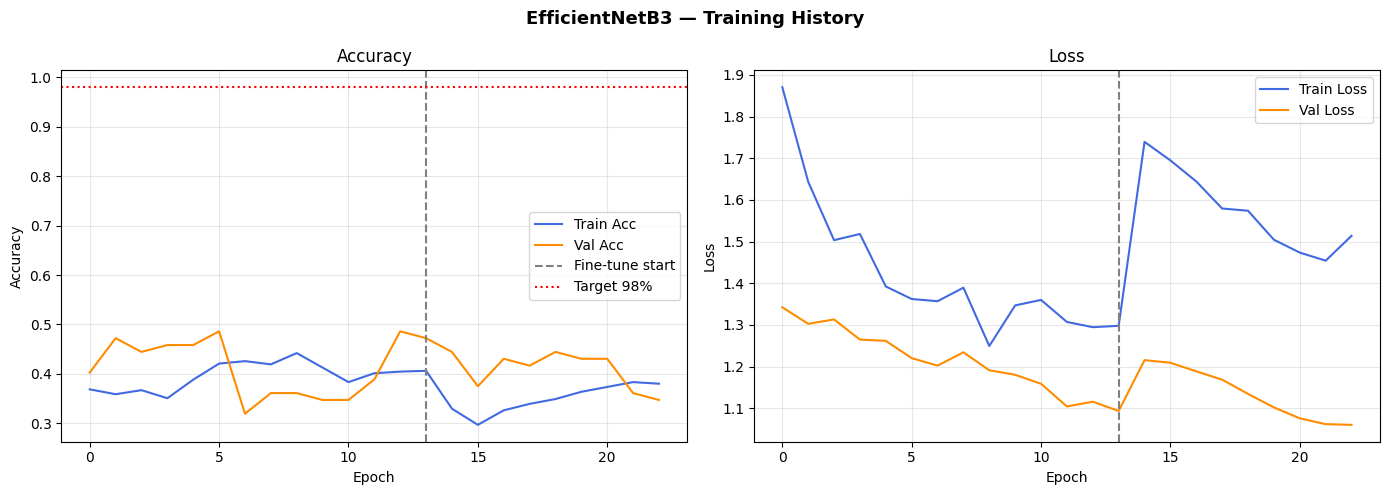

Plot saved to weights\EfficientNetB3\training_history.png

✓ EfficientNetB3 complete — Test Accuracy: 51.11%


In [56]:
all_results = {}

# ── Train EfficientNetB3 ───────────────────────────────────────────────
results_b3 = train_model("EfficientNetB3", fine_tune_layers=30)
all_results["EfficientNetB3"] = results_b3
print(f"\n✓ EfficientNetB3 complete — Test Accuracy: {results_b3['test_accuracy']*100:.2f}%")


  Training: EfficientNetB4
Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Class weights: {0: 0.7858974358974359, 1: 1.3326086956521739, 2: 1.035472972972973, 3: 0.9887096774193549}

[Phase 1] Training head (base frozen)...
Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3530 - auc: 0.5799 - loss: 1.9800 - precision: 0.3525 - recall: 0.2468
Epoch 1: val_accuracy improved from None to 0.18056, saving model to weights\EfficientNetB4\best_phase1.keras

Epoch 1: finished saving model to weights\EfficientNetB4\best_phase1.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.3768 - auc: 0.6260 - loss: 1.7765 - precision: 0.4000 - recall: 0.2838 - val_accuracy: 0.1806 - val_auc: 0.5041 - val_loss: 1.4352 - val_precision: 1.0000 - val_recall: 0.0278 - learning_rate: 0.0010
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3828 - auc: 0.6310 - loss: 1.6234 - precision: 0.3890 - recall: 0


Classification Report:
                         precision    recall  f1-score   support

         Adenocarcinoma     0.0000    0.0000    0.0000       120
   Large Cell Carcinoma     0.1938    0.9804    0.3236        51
                 Normal     0.9474    1.0000    0.9730        54
Squamous Cell Carcinoma     0.0000    0.0000    0.0000        90

               accuracy                         0.3302       315
              macro avg     0.2853    0.4951    0.3241       315
           weighted avg     0.1938    0.3302    0.2192       315

Model saved to weights\EfficientNetB4\model.h5


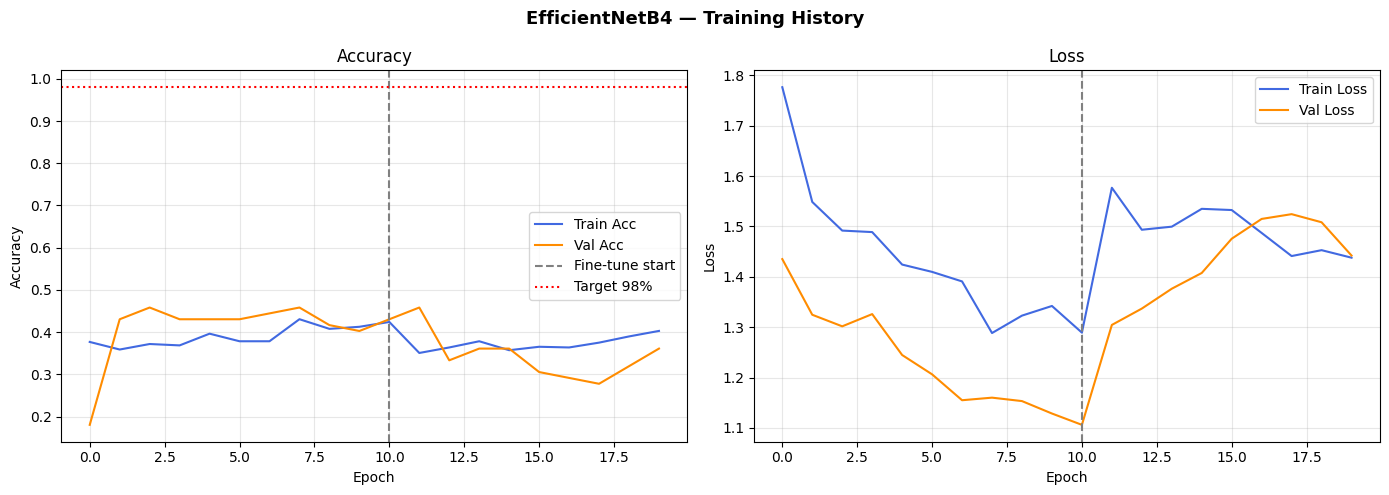

Plot saved to weights\EfficientNetB4\training_history.png

✓ EfficientNetB4 complete — Test Accuracy: 33.02%


In [57]:
# ── Train EfficientNetB4 ───────────────────────────────────────────────
results_b4 = train_model("EfficientNetB4", fine_tune_layers=40)
all_results["EfficientNetB4"] = results_b4
print(f"\n✓ EfficientNetB4 complete — Test Accuracy: {results_b4['test_accuracy']*100:.2f}%")


  Training: ResNet50V2
Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Class weights: {0: 0.7858974358974359, 1: 1.3326086956521739, 2: 1.035472972972973, 3: 0.9887096774193549}

[Phase 1] Training head (base frozen)...
Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4086 - auc: 0.6568 - loss: 1.7494 - precision: 0.4216 - recall: 0.3459
Epoch 1: val_accuracy improved from None to 0.45833, saving model to weights\ResNet50V2\best_phase1.keras

Epoch 1: finished saving model to weights\ResNet50V2\best_phase1.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.4715 - auc: 0.7286 - loss: 1.5326 - precision: 0.4932 - recall: 0.4144 - val_accuracy: 0.4583 - val_auc: 0.7782 - val_loss: 1.1335 - val_precision: 0.5091 - val_recall: 0.3889 - learning_rate: 0.0010
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5508 - auc: 0.8255 - loss: 1.0896 - precision: 0.5826 - recall: 0.5062
Epoch 


Classification Report:
                         precision    recall  f1-score   support

         Adenocarcinoma     0.7805    0.5333    0.6337       120
   Large Cell Carcinoma     0.3543    0.8824    0.5056        51
                 Normal     1.0000    0.9815    0.9907        54
Squamous Cell Carcinoma     0.8302    0.4889    0.6154        90

               accuracy                         0.6540       315
              macro avg     0.7413    0.7215    0.6863       315
           weighted avg     0.7633    0.6540    0.6689       315

Model saved to weights\ResNet50V2\model.h5


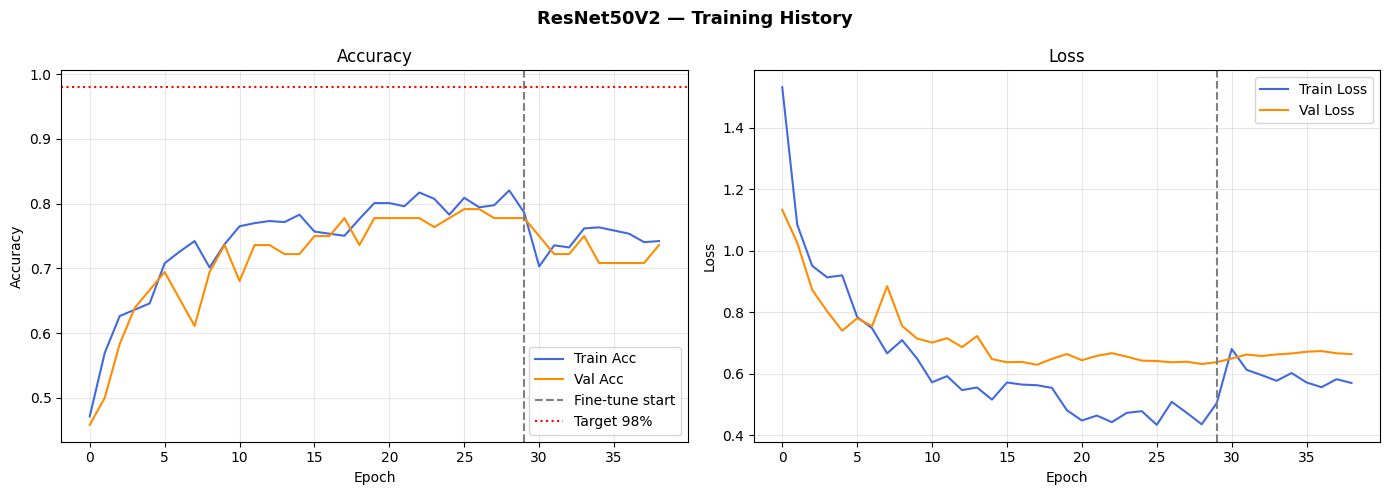

Plot saved to weights\ResNet50V2\training_history.png

✓ ResNet50V2 complete — Test Accuracy: 65.40%


In [58]:
# ── Train ResNet50V2 ───────────────────────────────────────────────────
results_rn = train_model("ResNet50V2", fine_tune_layers=20)
all_results["ResNet50V2"] = results_rn
print(f"\n✓ ResNet50V2 complete — Test Accuracy: {results_rn['test_accuracy']*100:.2f}%")

## 8. Model Comparison

In [59]:
print("\n" + "=" * 65)
print("  MODEL COMPARISON SUMMARY")
print("=" * 65)
print(f"{'Model':<18} {'Accuracy':>10} {'AUC':>8} {'Precision':>10} {'Recall':>8} {'Loss':>8}")
print("-" * 65)

best_name  = None
best_acc   = 0.0

for name, r in all_results.items():
    acc_pct = r['test_accuracy'] * 100
    marker  = " ★" if r['test_accuracy'] > best_acc else ""
    print(
        f"{name:<18} {acc_pct:>9.2f}%"
        f" {r['test_auc']:>8.4f}"
        f" {r['precision']:>10.4f}"
        f" {r['recall']:>8.4f}"
        f" {r['test_loss']:>8.4f}"
        f"{marker}"
    )
    if r['test_accuracy'] > best_acc:
        best_acc  = r['test_accuracy']
        best_name = name

print("=" * 65)
print(f"\nBest model : {best_name}")
print(f"Best acc   : {best_acc*100:.2f}%")
print(f"Target met : {'YES ✓' if best_acc >= TARGET_ACCURACY else 'NO — see Section 9'}")


  MODEL COMPARISON SUMMARY
Model                Accuracy      AUC  Precision   Recall     Loss
-----------------------------------------------------------------
EfficientNetB3         51.11%   0.7974     1.0000   0.0127   1.1947 ★
EfficientNetB4         33.02%   0.6165     1.0000   0.0254   1.3332
ResNet50V2             65.40%   0.8821     0.6633   0.6254   0.9577 ★

Best model : ResNet50V2
Best acc   : 65.40%
Target met : NO — see Section 9


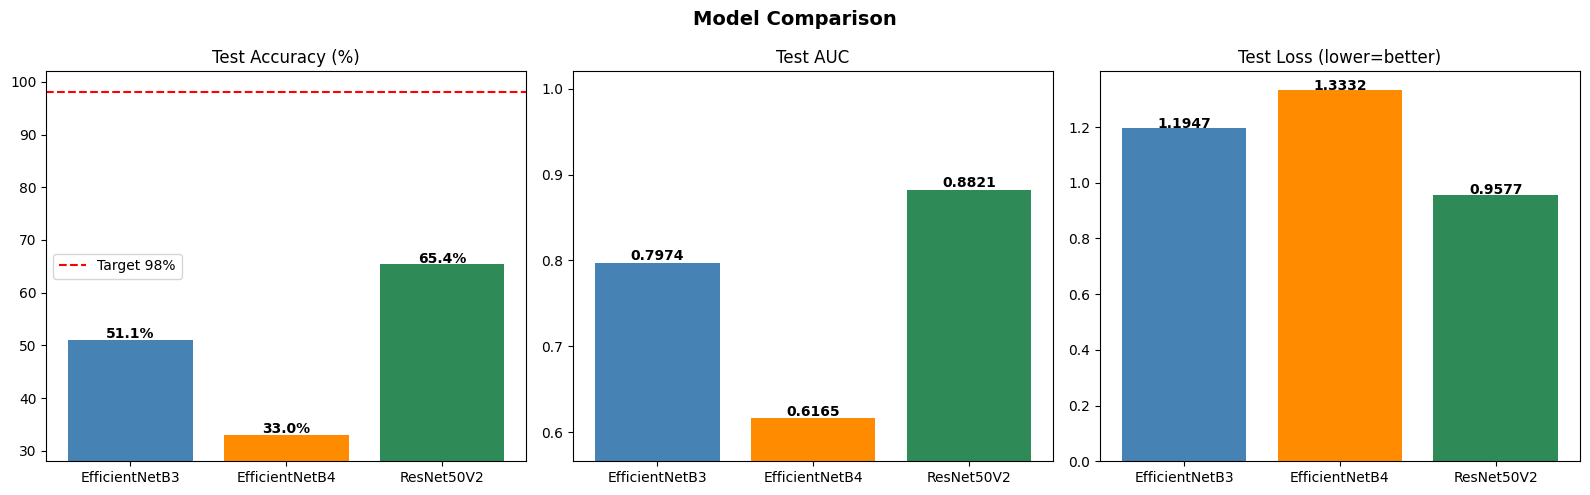

Comparison chart saved.


In [60]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison", fontsize=14, fontweight='bold')

names     = list(all_results.keys())
accs      = [all_results[n]['test_accuracy']*100 for n in names]
aucs      = [all_results[n]['test_auc']          for n in names]
losses    = [all_results[n]['test_loss']          for n in names]

colors = ['steelblue', 'darkorange', 'seagreen']

axes[0].bar(names, accs, color=colors)
axes[0].axhline(TARGET_ACCURACY*100, color='red', ls='--', label=f'Target {TARGET_ACCURACY*100:.0f}%')
axes[0].set_title("Test Accuracy (%)")
axes[0].set_ylim([max(0, min(accs)-5), 102])
axes[0].legend()
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha='center', fontweight='bold')

axes[1].bar(names, aucs, color=colors)
axes[1].set_title("Test AUC")
axes[1].set_ylim([max(0, min(aucs)-0.05), 1.02])
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.003, f"{v:.4f}", ha='center', fontweight='bold')

axes[2].bar(names, losses, color=colors)
axes[2].set_title("Test Loss (lower=better)")
for i, v in enumerate(losses):
    axes[2].text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / "model_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved.")

## 9. Confusion Matrix & Per-Class Analysis

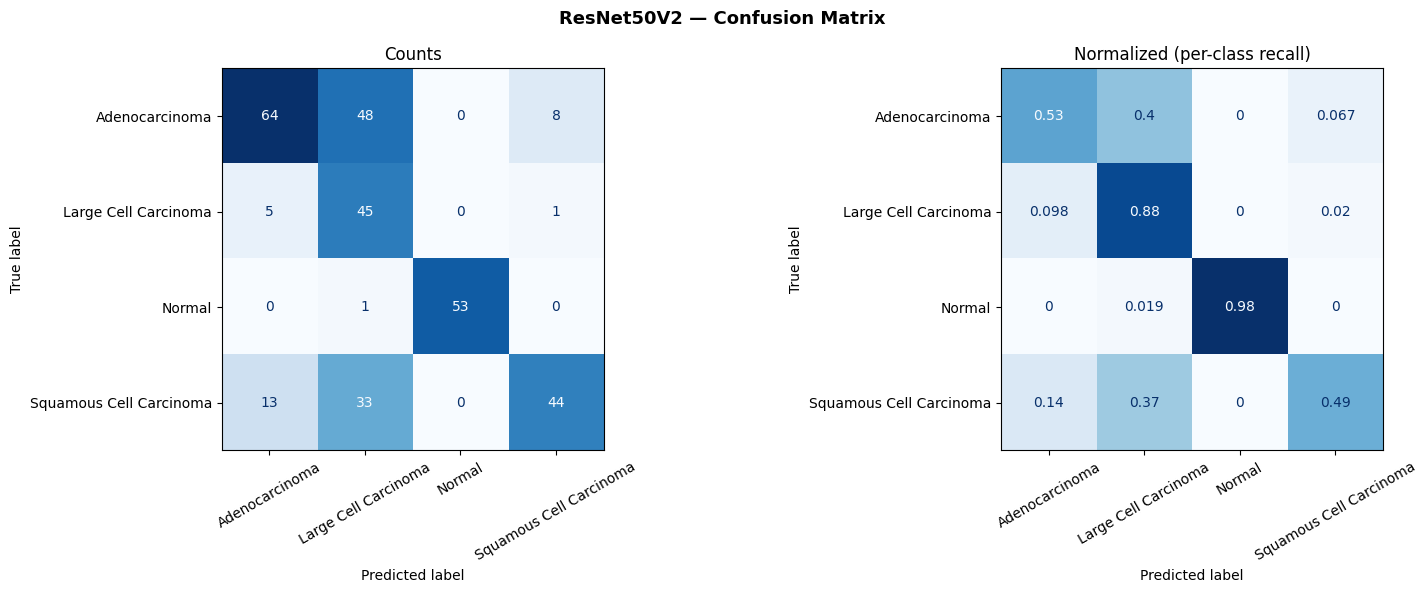

Confusion matrix saved.


In [61]:
best_r = all_results[best_name]

# Confusion matrix
cm = confusion_matrix(best_r['y_true'], best_r['y_pred'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"{best_name} — Confusion Matrix", fontsize=13, fontweight='bold')

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Counts")
axes[0].tick_params(axis='x', rotation=30)

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title("Normalized (per-class recall)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / f"{best_name}_confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")

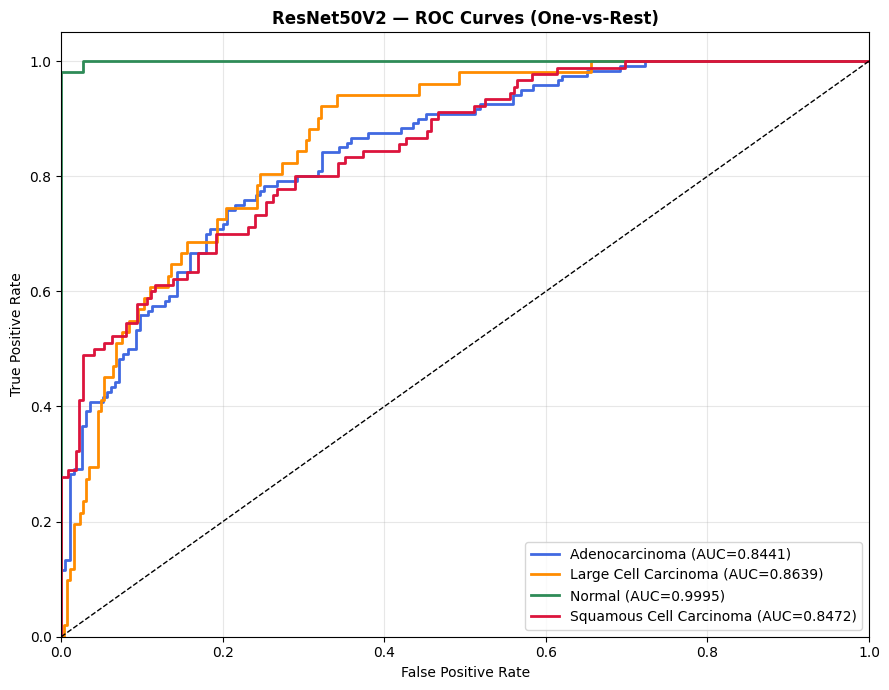

ROC curves saved.


In [62]:
# ROC curves (one-vs-rest)
y_true_bin = label_binarize(best_r['y_true'], classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['royalblue', 'darkorange', 'seagreen', 'crimson']

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], best_r['y_pred_probs'][:, i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{cls_name} (AUC={roc_auc_val:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"{best_name} — ROC Curves (One-vs-Rest)", fontweight='bold')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / f"{best_name}_roc_curves.png"), dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved.")

## 10. Grad-CAM Visualization

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.


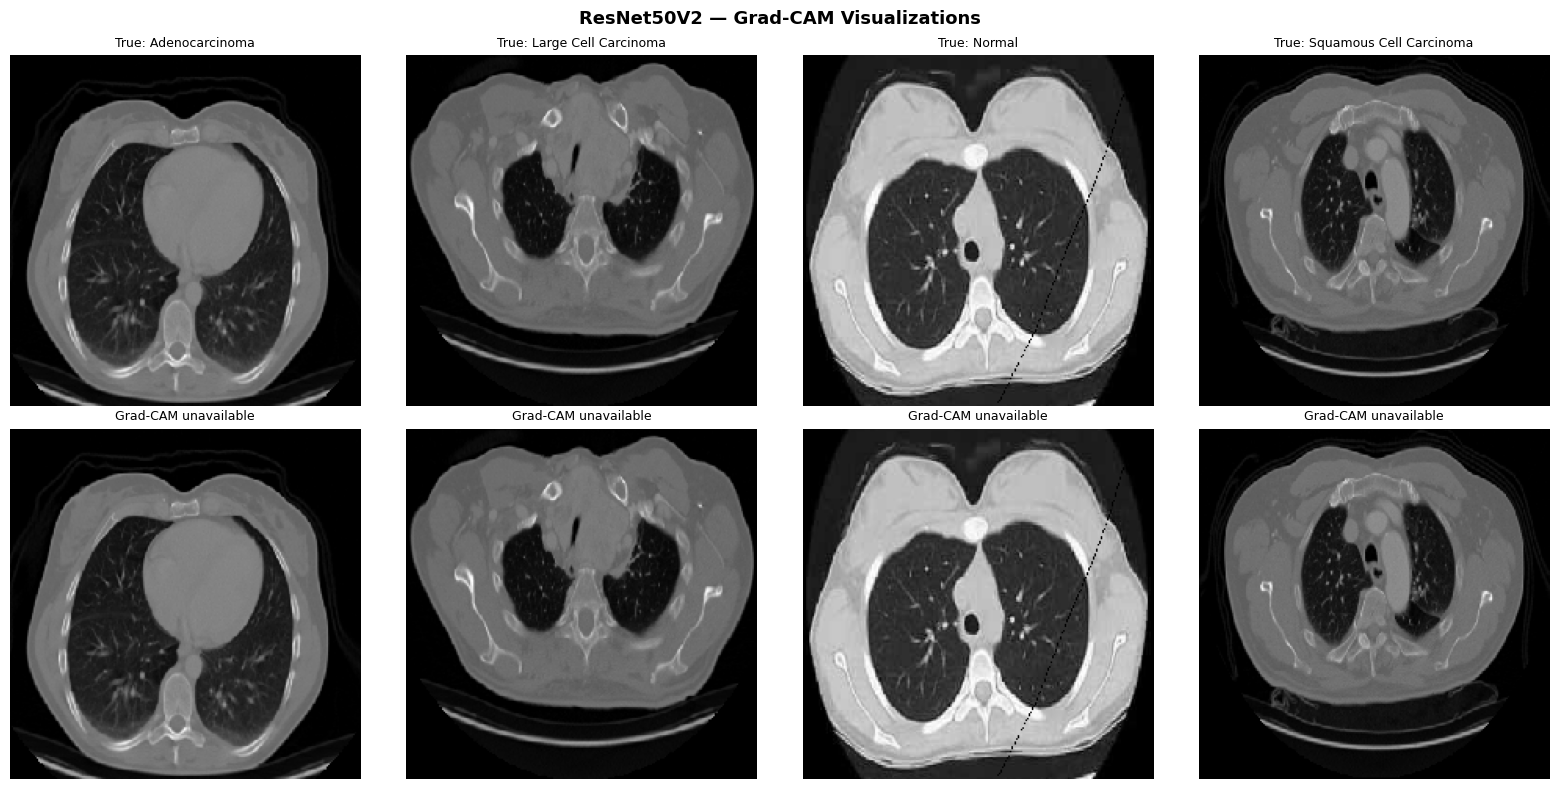

Grad-CAM visualization saved.


In [63]:
def make_gradcam(model, img_array, pred_class_idx):
    """Generate Grad-CAM heatmap overlay."""
    last_conv_name = None
    for layer in reversed(model.layers):
        if 'conv' in layer.name.lower():
            last_conv_name = layer.name
            break

    if not last_conv_name:
        return None

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        loss = preds[:, pred_class_idx]

    grads       = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap     = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap     = tf.squeeze(heatmap)
    heatmap     = np.maximum(heatmap.numpy(), 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    # Overlay
    orig_img    = Image.fromarray((img_array[0] * 255).astype(np.uint8))
    hm_resized  = np.uint8(255 * heatmap)
    hm_img      = Image.fromarray(hm_resized).resize(IMG_SIZE)
    colored     = cm.jet(np.array(hm_img) / 255.0)[:, :, :3]
    colored_img = Image.fromarray((colored * 255).astype(np.uint8))
    superimposed = Image.blend(orig_img.convert("RGB"), colored_img, alpha=0.4)
    return np.array(superimposed)


# Show Grad-CAM for one sample per class
best_model = best_r['model']
_, _, te_gen_gradcam = create_generators(batch_size=1)

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 8))
fig.suptitle(f"{best_name} — Grad-CAM Visualizations", fontsize=13, fontweight='bold')

shown = {cls: False for cls in range(NUM_CLASSES)}
te_gen_gradcam.reset()

for batch_x, batch_y in te_gen_gradcam:
    true_cls = int(np.argmax(batch_y[0]))
    if shown[true_cls]:
        continue

    pred_probs = best_model.predict(batch_x, verbose=0)[0]
    pred_cls   = int(np.argmax(pred_probs))
    conf       = pred_probs[pred_cls] * 100

    orig = (batch_x[0] * 255).astype(np.uint8)
    gcam = make_gradcam(best_model, batch_x, pred_cls)

    col = true_cls
    axes[0, col].imshow(orig)
    axes[0, col].set_title(f"True: {CLASS_NAMES[true_cls]}", fontsize=9)
    axes[0, col].axis('off')

    if gcam is not None:
        axes[1, col].imshow(gcam)
        correct = '✓' if pred_cls == true_cls else '✗'
        axes[1, col].set_title(f"Pred: {CLASS_NAMES[pred_cls]} {correct} ({conf:.1f}%)", fontsize=9)
    else:
        axes[1, col].imshow(orig)
        axes[1, col].set_title("Grad-CAM unavailable", fontsize=9)
    axes[1, col].axis('off')

    shown[true_cls] = True
    if all(shown.values()):
        break

plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / f"{best_name}_gradcam.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM visualization saved.")

## 11. Deploy Best Model

In [64]:
import shutil

print("\n" + "=" * 60)
print("  DEPLOYMENT")
print("=" * 60)
print(f"  Best model      : {best_name}")
print(f"  Test accuracy   : {best_acc*100:.2f}%")
print(f"  Target (≥98%)   : {'ACHIEVED ✓' if best_acc >= TARGET_ACCURACY else 'NOT MET — see note below'}")
print()

# Source: where the model was saved during training
src = WEIGHTS_DIR / best_name / "model.h5"

# Destination 1: ml_model/weights/lung_cancer_model.h5
dst_ml = WEIGHTS_DIR / "lung_cancer_model.h5"

# Destination 2: backend/ml_model/weights/lung_cancer_model.h5
backend_weights_dir = BASE_DIR.parent / "backend" / "ml_model" / "weights"
backend_weights_dir.mkdir(parents=True, exist_ok=True)
dst_backend = backend_weights_dir / "lung_cancer_model.h5"

shutil.copy2(src, dst_ml)
shutil.copy2(src, dst_backend)

print(f"Model deployed to:")
print(f"  {dst_ml.resolve()}")
print(f"  {dst_backend.resolve()}")

# Save deployment metadata
meta = {
    "model_name":     best_name,
    "test_accuracy":  round(best_acc, 6),
    "test_auc":       round(best_r['test_auc'], 6),
    "test_precision": round(best_r['precision'], 6),
    "test_recall":    round(best_r['recall'], 6),
    "test_loss":      round(best_r['test_loss'], 6),
    "img_size":       list(IMG_SIZE),
    "classes":        CLASS_NAMES,
    "trained_at":     datetime.now().isoformat(),
    "target_met":     bool(best_acc >= TARGET_ACCURACY),
}

with open(str(WEIGHTS_DIR / "deployment_info.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("\nDeployment metadata:")
print(json.dumps(meta, indent=2))

if best_acc < TARGET_ACCURACY:
    print("\n⚠ NOTE: Target accuracy not met with current dataset size (~1000 images).")
    print("  Run Section 12 (extended training with augmentation) to push further.")


  DEPLOYMENT
  Best model      : ResNet50V2
  Test accuracy   : 65.40%
  Target (≥98%)   : NOT MET — see note below

Model deployed to:
  D:\Projects\CapstoneProject\System\TRY_06\ml_model\weights\lung_cancer_model.h5
  D:\Projects\CapstoneProject\System\TRY_06\ml_model\backend\ml_model\weights\lung_cancer_model.h5

Deployment metadata:
{
  "model_name": "ResNet50V2",
  "test_accuracy": 0.653968,
  "test_auc": 0.882083,
  "test_precision": 0.6633,
  "test_recall": 0.625397,
  "test_loss": 0.957701,
  "img_size": [
    224,
    224
  ],
  "classes": [
    "Adenocarcinoma",
    "Large Cell Carcinoma",
    "Normal",
    "Squamous Cell Carcinoma"
  ],
  "trained_at": "2026-06-10T01:18:53.878782",
  "target_met": false
}

⚠ NOTE: Target accuracy not met with current dataset size (~1000 images).
  Run Section 12 (extended training with augmentation) to push further.


## 12. Extended Training (if target not met)

Only run this if the best model didn't reach 98%. This section applies stronger augmentation and longer training.

In [65]:
# Only execute if target not yet met
if best_acc < TARGET_ACCURACY:
    print(f"Current best: {best_acc*100:.2f}% — running extended training on {best_name}...")

    def create_extended_generators():
        """Stronger augmentation for extended training."""
        train_datagen = ImageDataGenerator(
            rescale=1.0 / 255,
            rotation_range=30,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=True,
            brightness_range=[0.8, 1.2],
            channel_shift_range=20.0,
            fill_mode="nearest",
        )
        val_datagen = ImageDataGenerator(rescale=1.0 / 255)

        t = train_datagen.flow_from_directory(
            str(DATA_DIR / "train"),
            target_size=IMG_SIZE, batch_size=BATCH_SIZE,
            class_mode="categorical", classes=CLASS_NAMES,
            shuffle=True, seed=SEED,
        )
        v = val_datagen.flow_from_directory(
            str(DATA_DIR / "val"),
            target_size=IMG_SIZE, batch_size=BATCH_SIZE,
            class_mode="categorical", classes=CLASS_NAMES, shuffle=False,
        )
        te = val_datagen.flow_from_directory(
            str(DATA_DIR / "test"),
            target_size=IMG_SIZE, batch_size=BATCH_SIZE,
            class_mode="categorical", classes=CLASS_NAMES, shuffle=False,
        )
        return t, v, te

    ext_t, ext_v, ext_te = create_extended_generators()
    ext_class_weights = compute_class_weights(ext_t)

    # Load best model and continue fine-tuning with even lower LR
    best_model_ext = tf.keras.models.load_model(str(WEIGHTS_DIR / best_name / "model.h5"))

    # Unfreeze more layers
    for layer in best_model_ext.layers:
        if hasattr(layer, 'layers'):
            for l in layer.layers[-60:]:
                l.trainable = True

    best_model_ext.compile(
        optimizer=optimizers.AdamW(1e-6, weight_decay=1e-6),
        loss="categorical_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )

    ext_callbacks = [
        callbacks.EarlyStopping(monitor="val_accuracy", patience=10,
                                restore_best_weights=True, min_delta=0.001, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2,
                                    patience=3, min_lr=1e-9, verbose=1),
        callbacks.ModelCheckpoint(
            str(WEIGHTS_DIR / best_name / "best_extended.keras"),
            monitor="val_accuracy", save_best_only=True, verbose=1,
        ),
    ]

    h_ext = best_model_ext.fit(
        ext_t, epochs=25, validation_data=ext_v,
        callbacks=ext_callbacks, class_weight=ext_class_weights, verbose=1,
    )

    ext_te.reset()
    ext_results = best_model_ext.evaluate(ext_te, verbose=1)
    ext_acc = ext_results[1]
    print(f"\nExtended training accuracy: {ext_acc*100:.2f}%")

    if ext_acc > best_acc:
        best_acc = ext_acc
        best_model = best_model_ext
        # Re-deploy
        best_model.save(str(dst_ml))
        best_model.save(str(dst_backend))
        print(f"Improved model re-deployed! Accuracy: {best_acc*100:.2f}%")
    else:
        print("Extended training did not improve — keeping original.")
else:
    print(f"Target already met ({best_acc*100:.2f}%) — skipping extended training.")

Current best: 65.40% — running extended training on ResNet50V2...
Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Class weights: {0: 0.7858974358974359, 1: 1.3326086956521739, 2: 1.035472972972973, 3: 0.9887096774193549}


Epoch 1/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5688 - auc: 0.8379 - loss: 1.1202
Epoch 1: val_accuracy improved from None to 0.75000, saving model to weights\ResNet50V2\best_extended.keras

Epoch 1: finished saving model to weights\ResNet50V2\best_extended.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.5546 - auc: 0.8238 - loss: 1.1855 - val_accuracy: 0.7500 - val_auc: 0.9220 - val_loss: 0.7322 - learning_rate: 1.0000e-06
Epoch 2/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5450 - auc: 0.8183 - loss: 1.2513
Epoch 2: val_accuracy did not improve from 0.75000
39/39 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.5530 - auc: 0.8209 - loss: 1.2247 - val_accuracy: 0.6806 - val_auc: 0.9152 - val_loss: 0.7586 - learning_rate: 1.0000e-06
Epoch 3/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5208 - auc: 0.8091 - loss: 1.2877
Epoch 3: val_accuracy did not improve from 0.75000
39/39 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.5400 - auc: 0.8044 -

## 13. Final Summary

In [66]:
print("\n" + "★" * 60)
print("  FINAL SUMMARY")
print("★" * 60)
print(f"  Project         : PulmoScan AI")
print(f"  Task            : Lung Cancer CT Scan Classification (4 classes)")
print(f"  Best model      : {best_name}")
print(f"  Test accuracy   : {best_acc*100:.2f}%")
print(f"  Target (≥98%)   : {'ACHIEVED ✓' if best_acc >= TARGET_ACCURACY else 'NOT MET — dataset may be too small'}")
print()
print("  Deployed to:")
print(f"  • {dst_ml.resolve()}")
print(f"  • {dst_backend.resolve()}")
print()
print("  Next steps:")
print("  1. cd to project root")
print("  2. docker-compose up --build")
print("  3. Open http://localhost:3000")
print("  4. Login: director@pulmoscan.ai / Director@2026!")
print("★" * 60)


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  FINAL SUMMARY
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  Project         : PulmoScan AI
  Task            : Lung Cancer CT Scan Classification (4 classes)
  Best model      : ResNet50V2
  Test accuracy   : 65.40%
  Target (≥98%)   : NOT MET — dataset may be too small

  Deployed to:
  • D:\Projects\CapstoneProject\System\TRY_06\ml_model\weights\lung_cancer_model.h5
  • D:\Projects\CapstoneProject\System\TRY_06\ml_model\backend\ml_model\weights\lung_cancer_model.h5

  Next steps:
  1. cd to project root
  2. docker-compose up --build
  3. Open http://localhost:3000
  4. Login: director@pulmoscan.ai / Director@2026!
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
